# EasyMoney — Limpieza de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_colwidth', None)

In [2]:
df_sal = pd.read_csv('../data/sales.csv', index_col=0)
df_cs = pd.read_csv('../data/customer_sociodemographics.csv', index_col=0)
df_cca = pd.read_csv('../data/customer_commercial_activity.csv', index_col=0)
df_cp = pd.read_csv('../data/customer_products.csv', index_col=0)
df_prd = pd.read_csv('../data/product_description.csv', index_col=0)

print('df_sal:', df_sal.shape)
print('df_cs:', df_cs.shape)
print('df_cca:', df_cca.shape)
print('df_cp:', df_cp.shape)
print('df_prd:', df_prd.shape)

df_sal: (240773, 5)
df_cs: (5962924, 8)
df_cca: (5962924, 6)
df_cp: (5962924, 17)
df_prd: (13, 3)


# 1.1 Limpieza sales.csv

In [3]:
print(df_sal.dtypes)
print('\n')
print(df_sal.isnull().sum())

pk_sale         int64
cid             int64
month_sale     object
product_ID      int64
net_margin    float64
dtype: object


pk_sale       0
cid           0
month_sale    0
product_ID    0
net_margin    0
dtype: int64


In [4]:
df_sal.head()

,pk_sale,cid,month_sale,product_ID,net_margin
0,6666,33620,2018-05-01,2335,952.90
1,6667,35063,2018-06-01,2335,1625.20
2,6668,37299,2018-02-01,2335,1279.70
3,6669,39997,2018-02-01,2335,1511.90
4,6670,44012,2018-02-01,2335,1680.30


In [5]:
#Convertimos la columna 'month_sale' a tipo datetime a tipo string dejando solo el año y el mes
df_sal['month_sale'] = pd.to_datetime(df_sal['month_sale']).dt.strftime('%Y-%m')

In [6]:
df_sal.describe()

,pk_sale,cid,product_ID,net_margin
count,240773.00,240773.00,240773.00,240773.00
mean,127052.00,1363933.72,3945.41,606.88
std,69505.32,175172.07,1632.82,1735.81
min,6666.00,15891.00,1119.00,25.00
25%,66859.00,1301012.00,2312.00,61.40
50%,127052.00,1409253.00,4657.00,69.10
75%,187245.00,1475320.00,4657.00,79.20
max,247438.00,1553571.00,9001.00,18466.40


count   240773.00
mean       606.88
std       1735.81
min         25.00
25%         61.40
50%         69.10
75%         79.20
max      18466.40
Name: net_margin, dtype: float64


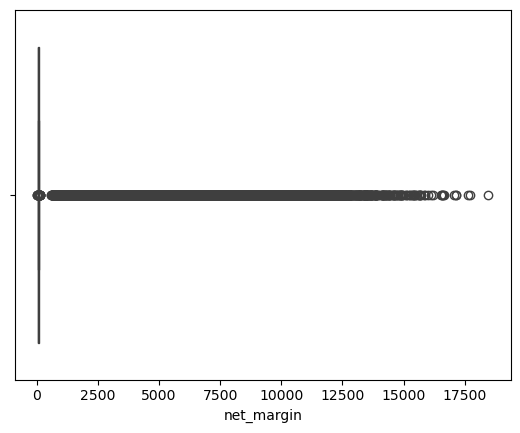

In [7]:
#Comprobación de outliers en la columna 'net_margin' mediante un boxplot
print(df_sal['net_margin'].describe())
sns.boxplot(x='net_margin', data=df_sal)
plt.show()

In [8]:
#Investigamos los outliers
df_sal[df_sal['net_margin'] > 5000].groupby('product_ID')['net_margin'].describe()

,count,mean,std,min,25%,50%,75%,max
product_ID,,,,,,,,
1364,12120.00,7213.23,1850.00,5000.40,5812.48,6760.90,8139.12,18466.40
4033,1.00,5360.50,NaN,5360.50,5360.50,5360.50,5360.50,5360.50


In [9]:

df_sal[df_sal['product_ID'] == 1364]['net_margin'].describe()

count   19369.00
mean     5976.44
std      2215.89
min      1376.50
25%      4379.90
50%      5641.10
75%      7215.60
max     18466.40
Name: net_margin, dtype: float64

In [10]:
#Contamos el número de registros con product_ID 1364 y net_margin mayor a 10000
df_sal[(df_sal['product_ID'] == 1364) & (df_sal['net_margin'] > 10000)].shape[0]

1043

# 1.2 Limpieza customer_cosiodemographics

In [11]:
print(df_cs.dtypes)
print('\n')
print(df_cs.isnull().sum())

pk_cid            int64
pk_partition     object
country_id       object
region_code     float64
gender           object
age               int64
deceased         object
salary          float64
dtype: object


pk_cid                0
pk_partition          0
country_id            0
region_code        2264
gender               25
age                   0
deceased              0
salary          1541104
dtype: int64


In [12]:
df_cs.head()

,pk_cid,pk_partition,country_id,region_code,gender,age,deceased,salary
0,1375586,2018-01,ES,29.00,H,35,N,87218.10
1,1050611,2018-01,ES,13.00,V,23,N,35548.74
2,1050612,2018-01,ES,13.00,V,23,N,122179.11
3,1050613,2018-01,ES,50.00,H,22,N,119775.54
4,1050614,2018-01,ES,50.00,V,23,N,NaN


In [13]:
#Tratamiento de valores nulos en la columna 'gender'
df_cs['gender'].fillna(df_cs['gender'].mode()[0], inplace=True)

/var/folders/p0/1jrq036d227bq3jf786p48zw0000gn/T/ipykernel_97165/4191315121.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cs['gender'].fillna(df_cs['gender'].mode()[0], inplace=True)


In [14]:
df_cs.groupby('country_id', dropna=False)['region_code'].count()

country_id
AR          0
AT          0
BE          0
BR          0
CA          0
CH          0
CI          0
CL          0
CM          0
CN          0
CO          0
DE          0
DJ          0
DO          0
DZ          0
ES    5960660
ET          0
FR          0
GA          0
GB          0
GT          0
HU          0
IE          0
IT          0
JM          0
LU          0
MA          0
MR          0
MX          0
NO          0
PE          0
PL          0
PT          0
QA          0
RO          0
RU          0
SA          0
SE          0
SN          0
US          0
VE          0
Name: region_code, dtype: int64

In [15]:
# Tratamiento de nulos 'region_code' vamos a imputar con 0, son todos extranjeros y no tenemos información de su región, por lo que imputar con 0 es una opción razonable.
df_cs.loc[df_cs['region_code'].isnull(), 'region_code'] = 0.0

In [16]:
print(df_cs['salary'].describe())
print(f'\nPorcentaje nulos: {df_cs["salary"].isnull().mean()*100:.1f}%')

count    4421820.00
mean      115583.29
std       200006.64
min         1202.73
25%        61415.32
50%        88441.47
75%       131309.22
max     28894395.51
Name: salary, dtype: float64

Porcentaje nulos: 25.8%


In [17]:
#Tratamientos de valores nulos en la columna 'salary', por la mediana para powerbi no es revelante
df_cs['salary'] = df_cs['salary'].fillna(df_cs['salary'].median())

# 1.3 Limpieza Customer_commercial_activity

In [18]:
print(df_cca.dtypes)
print('\n')
print(df_cca.isnull().sum())

pk_cid               int64
pk_partition        object
entry_date          object
entry_channel       object
active_customer    float64
segment             object
dtype: object


pk_cid                  0
pk_partition            0
entry_date              0
entry_channel      133033
active_customer         0
segment            133944
dtype: int64


In [19]:
df_cca.head()

,pk_cid,pk_partition,entry_date,entry_channel,active_customer,segment
0,1375586,2018-01,2018-01,KHL,1.00,02 - PARTICULARES
1,1050611,2018-01,2015-08,KHE,0.00,03 - UNIVERSITARIO
2,1050612,2018-01,2015-08,KHE,0.00,03 - UNIVERSITARIO
3,1050613,2018-01,2015-08,KHD,0.00,03 - UNIVERSITARIO
4,1050614,2018-01,2015-08,KHE,1.00,03 - UNIVERSITARIO


In [20]:
df_cca.groupby('entry_channel', dropna=False)['segment'].value_counts(normalize=True, dropna=False)

entry_channel  segment           
004            01 - TOP             1.00
007            02 - PARTICULARES    0.64
               01 - TOP             0.36
               NaN                  0.00
013            02 - PARTICULARES    0.89
                                    ... 
RED            NaN                  0.00
NaN            NaN                  1.00
               02 - PARTICULARES    0.00
               03 - UNIVERSITARIO   0.00
               01 - TOP             0.00
Name: proportion, Length: 162, dtype: float64

In [21]:
print('Nulos en ambos a la vez:', (df_cca['entry_channel'].isnull() & df_cca['segment'].isnull()).sum())
print('Nulos solo en entry_channel:', (df_cca['entry_channel'].isnull() & df_cca['segment'].notnull()).sum())
print('Nulos solo en segment:', (df_cca['entry_channel'].notnull() & df_cca['segment'].isnull()).sum())

Nulos en ambos a la vez: 132423
Nulos solo en entry_channel: 610
Nulos solo en segment: 1521


In [22]:
# Caso 1: los dos nulos → Desconocido
df_cca.loc[df_cca['entry_channel'].isnull(), 'entry_channel'] = 'Desconocido'
df_cca.loc[df_cca['segment'].isnull(), 'segment'] = 'Desconocido'

# Caso 2: entry_channel nulo pero segment tiene valor → moda de entry_channel por segment
moda_channel = df_cca.groupby('segment')['entry_channel'].transform(
    lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Desconocido'
)
df_cca.loc[(df_cca['entry_channel'].isnull()) & (df_cca['segment'].notnull()), 'entry_channel'] = moda_channel

# Caso 3: entry_channel tiene valor pero segment nulo → moda de segment por entry_channel
moda_segment = df_cca.groupby('entry_channel')['segment'].transform(
    lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Desconocido'
)
df_cca.loc[(df_cca['entry_channel'].notnull()) & (df_cca['segment'].isnull()), 'segment'] = moda_segment

# 1.4 Limpieza customer_products

In [23]:
print(df_cp.dtypes)
print('\n')
print(df_cp.isnull().sum())

pk_cid                  int64
pk_partition           object
short_term_deposit      int64
loans                   int64
mortgage                int64
funds                   int64
securities              int64
long_term_deposit       int64
em_account_pp           int64
credit_card             int64
payroll               float64
pension_plan          float64
payroll_account         int64
emc_account             int64
debit_card              int64
em_account_p            int64
em_acount               int64
dtype: object


pk_cid                 0
pk_partition           0
short_term_deposit     0
loans                  0
mortgage               0
funds                  0
securities             0
long_term_deposit      0
em_account_pp          0
credit_card            0
payroll               61
pension_plan          61
payroll_account        0
emc_account            0
debit_card             0
em_account_p           0
em_acount              0
dtype: int64


In [24]:
df_cp.describe()

,pk_cid,short_term_deposit,loans,mortgage,funds,securities,long_term_deposit,em_account_pp,credit_card,payroll,pension_plan,payroll_account,emc_account,debit_card,em_account_p,em_acount
count,5962924.00,5962924.00,5962924.00,5962924.00,5962924.00,5962924.00,5962924.00,5962924.00,5962924.00,5962863.00,5962863.00,5962924.00,5962924.00,5962924.00,5962924.00,5962924.00
mean,1234929.80,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.01,0.03,0.04,0.06,0.05,0.09,0.00,0.73
std,162302.04,0.05,0.01,0.01,0.06,0.06,0.13,0.00,0.11,0.18,0.19,0.23,0.23,0.29,0.00,0.44
min,15891.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1112532.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,1231097.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
75%,1352339.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
max,1553689.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [25]:
print(df_cp['payroll'].value_counts(dropna=False))
print(df_cp['pension_plan'].value_counts(dropna=False))

payroll
0.00    5757076
1.00     205787
NaN          61
Name: count, dtype: int64
pension_plan
0.00    5745061
1.00     217802
NaN          61
Name: count, dtype: int64


In [26]:
#Tratamiento de valores nulos con la mediana para 'payroll' y 'pension_plan'
df_cp['payroll'] = df_cp['payroll'].fillna(df_cp['payroll'].median())
df_cp['pension_plan'] = df_cp['pension_plan'].fillna(df_cp['pension_plan'].median())

# 1.5 Limpieza product_description

In [27]:
print(df_prd.isnull().sum())

pk_product_ID     0
product_desc      0
family_product    0
dtype: int64


In [28]:
#Merge de los dataframes df_sal, df_cs, df_cca y df_cp en un único dataframe df_final
df_merge1 = pd.merge(df_sal, df_cs, left_on=['month_sale', 'cid'], right_on=['pk_partition', 'pk_cid'], how='left', suffixes=('_sal', '_cs'))
df_merge2 = pd.merge(df_merge1, df_cca, left_on=['month_sale', 'cid'], right_on=['pk_partition', 'pk_cid'], how='left', suffixes=('_cs', '_cca'))
df_merge3 = pd.merge(df_merge2, df_cp, left_on=['month_sale', 'cid'], right_on=['pk_partition', 'pk_cid'], how='left', suffixes=('_cca', '_cp'))
df = pd.merge(df_merge3, df_prd, left_on='product_ID', right_on='pk_product_ID', how='left')

In [29]:
print(df.shape)
print(df.columns)

(240773, 39)
Index(['pk_sale', 'cid', 'month_sale', 'product_ID', 'net_margin', 'pk_cid_cs',
       'pk_partition_cs', 'country_id', 'region_code', 'gender', 'age',
       'deceased', 'salary', 'pk_cid_cca', 'pk_partition_cca', 'entry_date',
       'entry_channel', 'active_customer', 'segment', 'pk_cid', 'pk_partition',
       'short_term_deposit', 'loans', 'mortgage', 'funds', 'securities',
       'long_term_deposit', 'em_account_pp', 'credit_card', 'payroll',
       'pension_plan', 'payroll_account', 'emc_account', 'debit_card',
       'em_account_p', 'em_acount', 'pk_product_ID', 'product_desc',
       'family_product'],
      dtype='object')


In [30]:
provincias = {
    1: 'Álava', 2: 'Albacete', 3: 'Alicante', 4: 'Almería', 5: 'Ávila',
    6: 'Badajoz', 7: 'Baleares', 8: 'Barcelona', 9: 'Burgos', 10: 'Cáceres',
    11: 'Cádiz', 12: 'Castellón', 13: 'Ciudad Real', 14: 'Córdoba', 15: 'A Coruña',
    16: 'Cuenca', 17: 'Girona', 18: 'Granada', 19: 'Guadalajara', 20: 'Gipuzkoa',
    21: 'Huelva', 22: 'Huesca', 23: 'Jaén', 24: 'León', 25: 'Lleida',
    26: 'La Rioja', 27: 'Lugo', 28: 'Madrid', 29: 'Málaga', 30: 'Murcia',
    31: 'Navarra', 32: 'Ourense', 33: 'Asturias', 34: 'Palencia', 35: 'Las Palmas',
    36: 'Pontevedra', 37: 'Salamanca', 38: 'Santa Cruz de Tenerife', 39: 'Cantabria',
    40: 'Segovia', 41: 'Sevilla', 42: 'Soria', 43: 'Tarragona', 44: 'Teruel',
    45: 'Toledo', 46: 'Valencia', 47: 'Valladolid', 48: 'Bizkaia', 49: 'Zamora',
    50: 'Zaragoza', 51: 'Ceuta', 52: 'Melilla', 0: 'Extranjero'
}
df['provincia'] = df['region_code'].map(provincias)

In [31]:
#Unificar types de columnas para evitar problemas en PowerBI
for col in ['region_code', 'active_customer', 'payroll', 'pension_plan']:
    df[col] = df[col].astype('Int64')  # Int64 con mayúscula soporta NaN

In [32]:
# Redondear columnas numéricas
df['net_margin'] = df['net_margin'].round(2)
df['salary'] = df['salary'].round(2)

In [33]:
# Unificar segment por cliente: usar el valor más frecuente (moda) en vez del mes a mes,
# para tener un segmento fijo y consistente por cliente en el dashboard
segment_mode = df_cca.groupby('pk_cid')['segment'].agg(lambda x: x.mode()[0])
df['segment'] = df['cid'].map(segment_mode)

In [34]:
#borramos columnas duplicadas
df = df.drop(columns=['pk_cid_cs', 'pk_partition_cs', 'pk_cid_cca', 'pk_partition_cca', 'pk_cid', 'pk_partition', 'pk_product_ID'])

In [35]:
df.to_csv('df_powerbi.csv', index=False, sep=';', decimal=',')